In [11]:
!pip install xarray cfgrib

In [9]:
!pip install cfgrib

In [5]:
import xarray as xr
import cfgrib 
import numpy as np
import pandas as pd

ds_t = xr.open_dataset("temperature.grib", engine="cfgrib")

skipping variable: paramId==235 shortName='skt'
Traceback (most recent call last):
  File "C:\Users\Taimur Ahmad\AppData\Roaming\Python\Python312\site-packages\cfgrib\dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\Taimur Ahmad\AppData\Roaming\Python\Python312\site-packages\cfgrib\dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='step' value=Variable(dimensions=(), data=24.0) new_value=Variable(dimensions=(), data=0.0)
skipping variable: paramId==139 shortName='stl1'
Traceback (most recent call last):
  File "C:\Users\Taimur Ahmad\AppData\Roaming\Python\Python312\site-packages\cfgrib\dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\Taimur Ahmad\AppData\Roaming\Python\Python312\site-packages\cfgrib\dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.Da

In [6]:
import xarray as xr

#loading only 2m temperature
ds = xr.open_dataset(
    "temperature.grib", 
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "2t"}}
)
ds


<xarray.Dataset>
Dimensions:     (time: 84, latitude: 1801, longitude: 3600)
Coordinates:
    number      int32 ...
  * time        (time) datetime64[ns] 2017-01-01 2017-02-01 ... 2023-12-01
    step        timedelta64[ns] ...
    surface     float64 ...
  * latitude    (latitude) float64 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude   (longitude) float64 0.0 0.1 0.2 0.3 ... 359.6 359.7 359.8 359.9
    valid_time  (time) datetime64[ns] ...
Data variables:
    t2m         (time, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-10T14:48 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
import xarray as xr

#loading 2m temperature variable
ds = xr.open_dataset(
    "temperature.grib", 
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "2t"}}
)

print("Data variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))
ds.info()


Data variables: ['t2m']
Coordinates: ['number', 'time', 'step', 'surface', 'latitude', 'longitude', 'valid_time']
xarray.Dataset {
dimensions:
	time = 84 ;
	latitude = 1801 ;
	longitude = 3600 ;

variables:
	int32 number() ;
		number:long_name = ensemble member numerical id ;
		number:units = 1 ;
		number:standard_name = realization ;
	datetime64[ns] time(time) ;
		time:long_name = initial time of forecast ;
		time:standard_name = forecast_reference_time ;
	timedelta64[ns] step() ;
		step:long_name = time since forecast_reference_time ;
		step:standard_name = forecast_period ;
	float64 surface() ;
		surface:long_name = original GRIB coordinate for key: level(surface) ;
		surface:units = 1 ;
	float64 latitude(latitude) ;
		latitude:units = degrees_north ;
		latitude:standard_name = latitude ;
		latitude:long_name = latitude ;
		latitude:stored_direction = decreasing ;
	float64 longitude(longitude) ;
		longitude:units = degrees_east ;
		longitude:standard_name = longitude ;
		longitude:l

In [15]:
temps = []
times = ds['time'].values

for t in times:
    try:
        temp_slice = ds['t2m'].sel(time=t, method='nearest').load()
        value = temp_slice.mean(dim=['latitude', 'longitude']).values
        temps.append((t, value))
    except Exception as e:
        print(f"Skipped time: {t} | Error: {e}")
import time
time.sleep(0.05)  #pausing after each iteration to avoid excess memory usage??


Skipped time: 2021-12-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-01-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-02-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-03-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-04-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-05-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-06-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-07-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-08-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-09-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-10-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-11-01T00:00:00.000000000 | Error: [Errno 22] Invalid argument
Skipped time: 2022-12-01T00:

In [17]:
import cfgrib

datasets = cfgrib.open_datasets("temperature.grib")
print(f"Number of subdatasets: {len(datasets)}")

for i, sub_ds in enumerate(datasets):
    print(f"Sub-dataset {i}: {list(sub_ds.data_vars)} | Times: {len(sub_ds['time'])}")


Number of subdatasets: 6
Sub-dataset 0: ['stl1'] | Times: 84
Sub-dataset 1: ['stl2'] | Times: 84
Sub-dataset 2: ['stl3'] | Times: 84
Sub-dataset 3: ['stl4'] | Times: 84
Sub-dataset 4: ['t2m', 'd2m'] | Times: 84
Sub-dataset 5: ['skt'] | Times: 84


In [19]:
ds = datasets[4]
temps = []

for t in ds['time'].values:
    try:
        temp = ds['t2m'].sel(time=t).mean(dim=['latitude', 'longitude']).values
        temps.append((t, temp - 273.15))
    except Exception as e:
        print(f"Failed at {t}: {e}")


Failed at 2021-12-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-01-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-02-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-03-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-04-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-05-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-06-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-07-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-08-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-09-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-10-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-11-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2022-12-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2023-01-01T00:00:00.000000000: [Errno 22] Invalid argument
Failed at 2023-02-01T00:00:00.0000

In [21]:
temps = []

for i in range(len(ds['time'])):
    try:
        # Access data directly by index, not value
        temp = ds['t2m'].isel(time=i).mean(dim=['latitude', 'longitude']).values
        time_val = ds['time'].values[i]
        temps.append((time_val, temp - 273.15))
    except Exception as e:
        print(f"Failed at index {i}: {e}")

#GRIB file's internal offsets are very likely corrupted or unreadable beyond a certain range. cfgrib cannot safely read many of the time steps.


Failed at index 59: [Errno 22] Invalid argument
Failed at index 60: [Errno 22] Invalid argument
Failed at index 61: [Errno 22] Invalid argument
Failed at index 62: [Errno 22] Invalid argument
Failed at index 63: [Errno 22] Invalid argument
Failed at index 64: [Errno 22] Invalid argument
Failed at index 65: [Errno 22] Invalid argument
Failed at index 66: [Errno 22] Invalid argument
Failed at index 67: [Errno 22] Invalid argument
Failed at index 68: [Errno 22] Invalid argument
Failed at index 69: [Errno 22] Invalid argument
Failed at index 70: [Errno 22] Invalid argument
Failed at index 71: [Errno 22] Invalid argument
Failed at index 72: [Errno 22] Invalid argument
Failed at index 73: [Errno 22] Invalid argument
Failed at index 74: [Errno 22] Invalid argument
Failed at index 75: [Errno 22] Invalid argument
Failed at index 76: [Errno 22] Invalid argument
Failed at index 77: [Errno 22] Invalid argument
Failed at index 78: [Errno 22] Invalid argument
Failed at index 79: [Errno 22] Invalid a

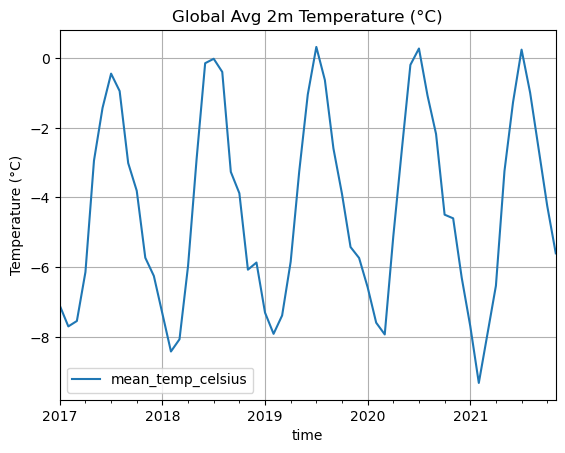

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(temps, columns=["time", "mean_temp"])
df["time"] = pd.to_datetime(df["time"])
df["mean_temp_celsius"] = df["mean_temp"] - 273.15

df.plot(x="time", y="mean_temp_celsius", title="Global Avg 2m Temperature (°C)")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

Skipped 2021-12-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-01-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-02-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-03-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-04-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-05-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-06-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-07-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-08-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-09-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-10-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-11-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-12-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2023-01-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2023-02-01T00:00:00.000000000: [Errno 22] Invalid argu

<Axes: title={'center': 'Global Mean 2m Temperature (°C)'}, xlabel='time'>

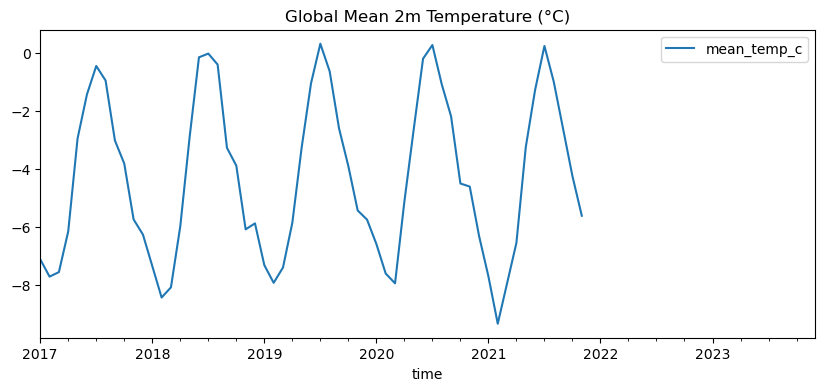

In [23]:
import numpy as np
import pandas as pd
#1. Global or Regional Mean Temperature Over Time
time_vals = ds['time'].values
mean_temps = []

for t in time_vals:
    try:
        temp = ds['t2m'].sel(time=t).mean(dim=['latitude', 'longitude']).values
        mean_temps.append(temp)
    except Exception as e:
        print(f"Skipped {t}: {e}")
        mean_temps.append(np.nan)
        
df = pd.DataFrame({
    'time': pd.to_datetime(time_vals),
    'mean_temp_k': mean_temps
})
df['mean_temp_c'] = df['mean_temp_k'] - 273.15

# Plot
df.plot(x='time', y='mean_temp_c', title='Global Mean 2m Temperature (°C)', figsize=(10, 4))

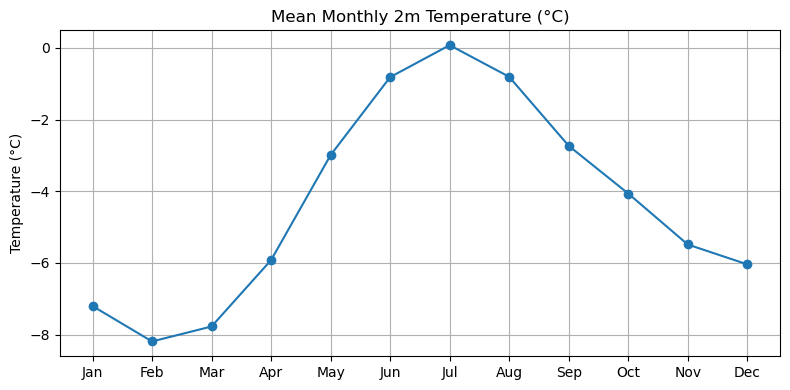

In [29]:
#2. Seasonal Cycle (Mean Monthly Temperature Across All Years)
import numpy as np
import pandas as pd

monthly_means = []

for month in range(1, 13):
    temps = []
    for t in ds['time'].values:
        if pd.to_datetime(t).month == month:
            try:
                val = ds['t2m'].sel(time=t).mean(dim=['latitude', 'longitude']).values
                temps.append(val)
            except:
                continue
    if temps:
        monthly_mean_k = np.mean(temps)
        monthly_means.append(monthly_mean_k - 273.15)  # Convert to Celsius
    else:
        monthly_means.append(np.nan)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, 13), monthly_means, marker='o')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Mean Monthly 2m Temperature (°C)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()



Skipped 2021-12-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-01-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-02-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-03-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-04-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-05-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-06-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-07-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-08-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-09-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-10-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-11-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2022-12-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2023-01-01T00:00:00.000000000: [Errno 22] Invalid argument
Skipped 2023-02-01T00:00:00.000000000: [Errno 22] Invalid argu

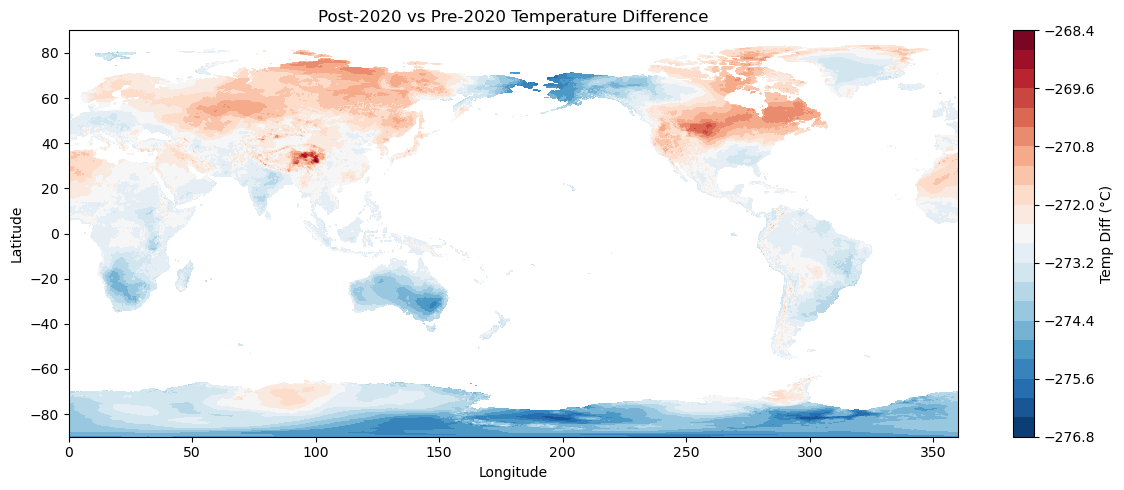

In [35]:
#3. Pre-2020 vs Post-2020 Temperature Difference Map
import numpy as np

def compute_mean_over_period(start, end):
    times = ds['time'].sel(time=slice(start, end)).values
    all_maps = []

    for t in times:
        try:
            temp_map = ds['t2m'].sel(time=t).values  # (lat, lon)
            all_maps.append(temp_map)
        except Exception as e:
            print(f"Skipped {t}: {e}")

    if all_maps:
        return np.mean(all_maps, axis=0)  # shape: (lat, lon)
    else:
        return None
        
pre_mean = compute_mean_over_period("2017-01-01", "2019-12-31")
post_mean = compute_mean_over_period("2020-01-01", "2023-12-31")

diff_map = (np.array(post_mean) - np.array(pre_mean))

lats = ds['latitude'].values
lons = ds['longitude'].values

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.contourf(lons, lats, diff_map - 273.15, levels=20, cmap='RdBu_r')
plt.colorbar(label='Temp Diff (°C)')
plt.title("Post-2020 vs Pre-2020 Temperature Difference")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Kerala Mean 2m Temperature (°C)'}, xlabel='time'>

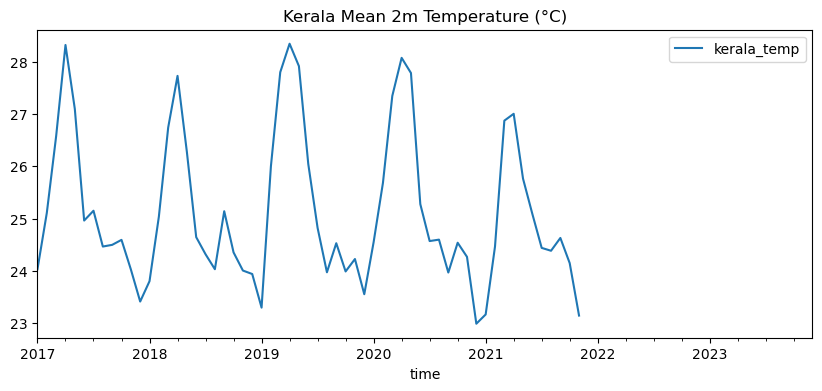

In [37]:
# 4. Kerala Region Time Series
kerala_temps = []

for t in time_vals:
    try:
        val = ds['t2m'].sel(time=t, latitude=slice(12.5, 8.0), longitude=slice(75, 78)).mean(dim=['latitude', 'longitude']).values
        kerala_temps.append(val - 273.15)
    except:
        kerala_temps.append(np.nan)

pd.DataFrame({'time': pd.to_datetime(time_vals), 'kerala_temp': kerala_temps}).plot(
    x='time', y='kerala_temp', title="Kerala Mean 2m Temperature (°C)", figsize=(10, 4)
)

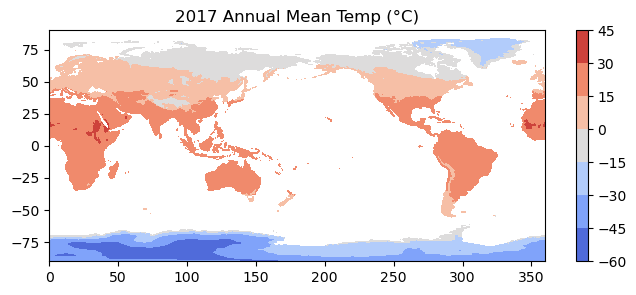

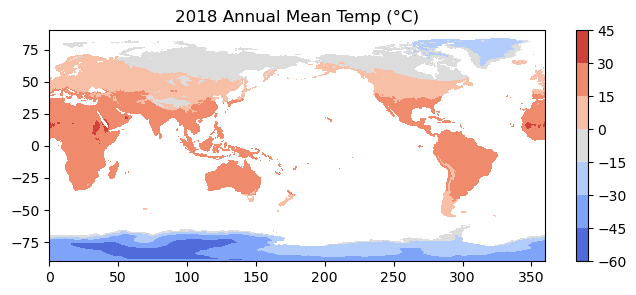

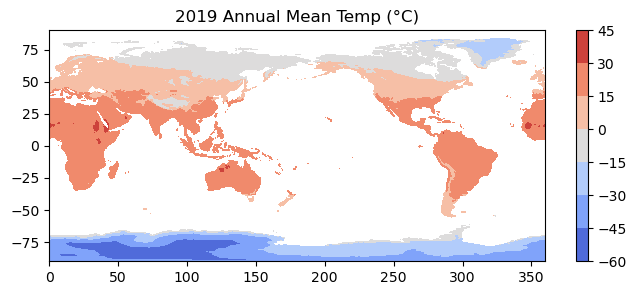

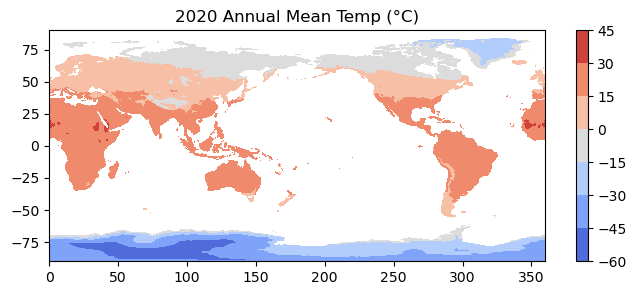

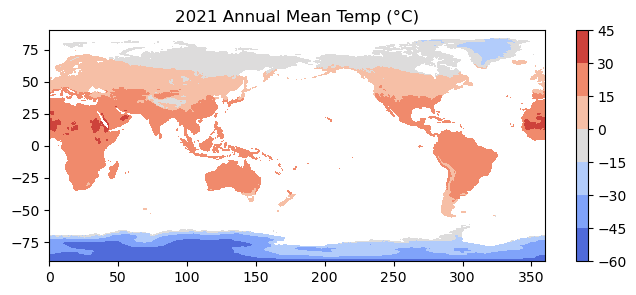

In [39]:
#5. Annual Mean Maps
years = range(2017, 2024)
maps = {}

for year in years:
    temps = []
    for t in time_vals:
        if pd.to_datetime(t).year == year:
            try:
                temps.append(ds['t2m'].sel(time=t).values)
            except:
                continue
    if temps:
        maps[year] = np.mean(temps, axis=0) - 273.15

for year, temp_map in maps.items():
    plt.figure(figsize=(8, 3))
    plt.contourf(ds['longitude'], ds['latitude'], temp_map, cmap='coolwarm')
    plt.title(f"{year} Annual Mean Temp (°C)")
    plt.colorbar()
    plt.show()


<Axes: title={'center': 'Global Temp Anomaly (°C)'}, xlabel='time'>

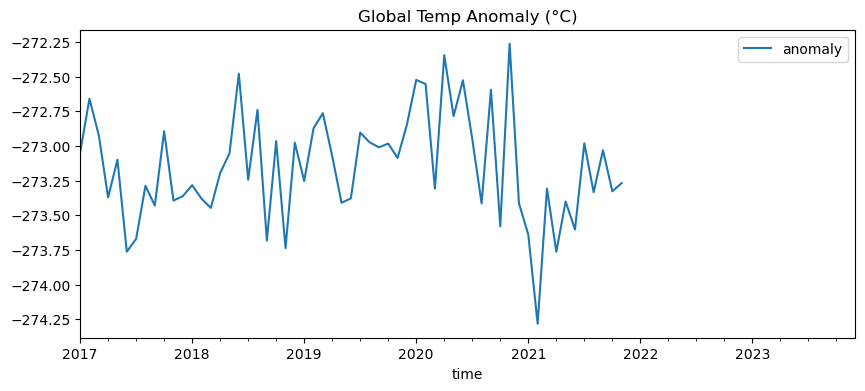

In [41]:
# 6. Temperature Anomalies
monthly_means_by_month = {m: [] for m in range(1, 13)}
for t in time_vals:
    try:
        month = pd.to_datetime(t).month
        val = ds['t2m'].sel(time=t).mean(dim=['latitude', 'longitude']).values
        monthly_means_by_month[month].append(val)
    except:
        continue

anomalies = []
for t in time_vals:
    try:
        month = pd.to_datetime(t).month
        current = ds['t2m'].sel(time=t).mean(dim=['latitude', 'longitude']).values
        clim = np.mean(monthly_means_by_month[month])
        anomalies.append((current - clim) - 273.15)
    except:
        anomalies.append(np.nan)

pd.DataFrame({'time': pd.to_datetime(time_vals), 'anomaly': anomalies}).plot(
    x='time', y='anomaly', title="Global Temp Anomaly (°C)", figsize=(10, 4)
)


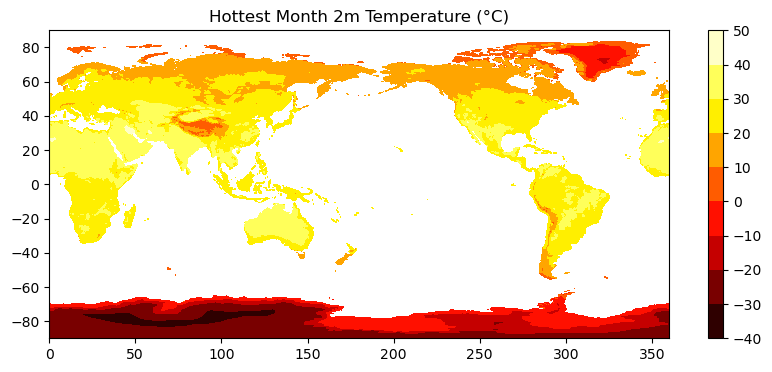

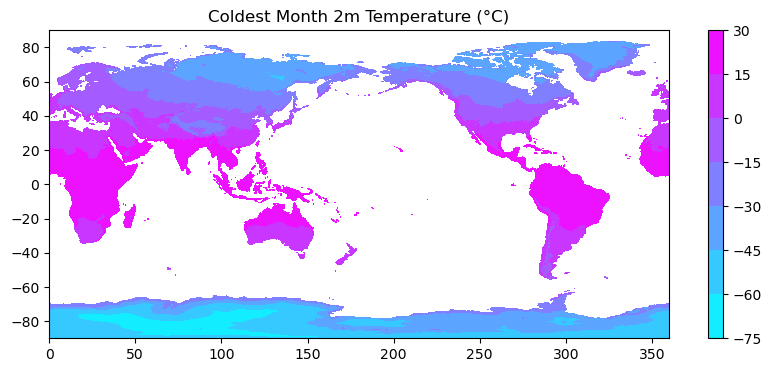

In [42]:
#7. Hottest/Coldest Month Map
max_temp = None
min_temp = None

for t in time_vals:
    try:
        current = ds['t2m'].sel(time=t).values
        if max_temp is None:
            max_temp = current
            min_temp = current
        else:
            max_temp = np.maximum(max_temp, current)
            min_temp = np.minimum(min_temp, current)
    except:
        continue

for data, title in [(max_temp, "Hottest Month"), (min_temp, "Coldest Month")]:
    plt.figure(figsize=(10, 4))
    plt.contourf(ds['longitude'], ds['latitude'], data - 273.15, cmap="hot" if title == "Hottest Month" else "cool")
    plt.title(f"{title} 2m Temperature (°C)")
    plt.colorbar()
    plt.show()


Skipped 2021-12-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-01-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-02-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-03-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-04-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-05-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-06-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-07-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-08-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-09-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-10-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-11-01T00:00:00.000000000 due to error: [Errno 22] Invalid argument
Skipped 2022-12-01T00:00:00.000000000 du

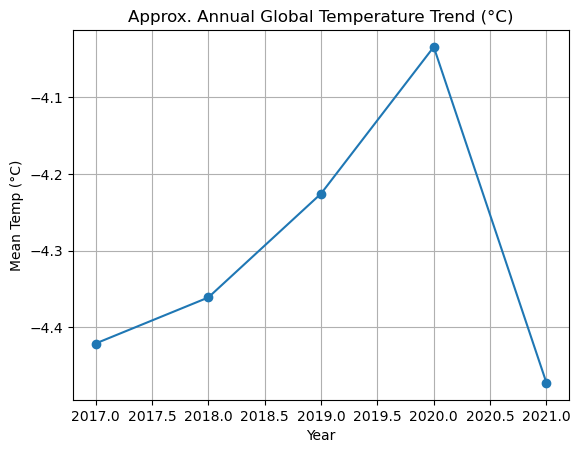

In [51]:
#8. Trend Estimate
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

years = list(range(2017, 2024))
year_means = []

for y in years:
    vals = []
    for t in time_vals:
        if pd.to_datetime(t).year == y:
            try:
                val = ds['t2m'].sel(time=t).mean(dim=['latitude', 'longitude']).values
                vals.append(val)
            except Exception as e:
                print(f"Skipped {t} due to error: {e}")
    if vals:
        year_means.append(np.mean(vals) - 273.15)  #celcius conversion
    else:
        print(f"No data for year {y}")
        year_means.append(np.nan)  # for handingling any possiblities of misssing years

plt.plot(years, year_means, marker='o')
plt.title("Approx. Annual Global Temperature Trend (°C)")
plt.xlabel("Year")
plt.ylabel("Mean Temp (°C)")
plt.grid(True)
plt.show()



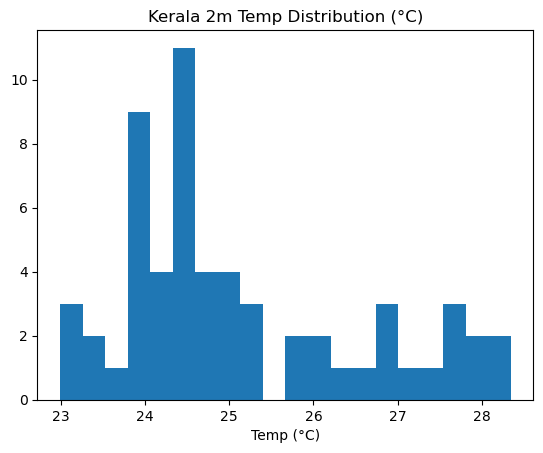

In [46]:
#9. Histogram of Kerala Temps
temps = []

for t in time_vals:
    try:
        val = ds['t2m'].sel(time=t, latitude=slice(12.5, 8.0), longitude=slice(75, 78)).mean(dim=['latitude', 'longitude']).values
        temps.append(val - 273.15)
    except:
        continue

pd.Series(temps).hist(bins=20)
plt.title("Kerala 2m Temp Distribution (°C)")
plt.xlabel("Temp (°C)")
plt.grid()
plt.show()


In [53]:
print(len(ds['time']))
print(ds['time'].values[:5])


84
['2017-01-01T00:00:00.000000000' '2017-02-01T00:00:00.000000000'
 '2017-03-01T00:00:00.000000000' '2017-04-01T00:00:00.000000000'
 '2017-05-01T00:00:00.000000000']


In [7]:
import pandas as pd

df_preview = pd.read_csv("cleaned_alldata_version2.csv", nrows=5)
print(df_preview.columns)



Index(['Unnamed: 0', 'Date_of_observation', 'Species_name', 'Lat', 'Long',
       'State_name', 'Leaves_fresh', 'Leaves_mature', 'Leaves_old',
       'Flowers_bud', 'Flowers_open', 'Flowers_male', 'Flowers_Female',
       'Fruits_unripe', 'Fruits_ripe', 'Fruits_open', 'Year', 'Week',
       'Species_id'],
      dtype='object')


In [9]:
import pandas as pd

phenology_df = pd.read_csv("cleaned_alldata_version2.csv", parse_dates=['Date_of_observation'])

phenology_df.rename(columns={
    'Date_of_observation': 'date',
    'Lat': 'lat',
    'Long': 'lon'
}, inplace=True)

phenology_df.head()


,Unnamed: 0,date,Species_name,lat,lon,State_name,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,Flowers_male,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open,Year,Week,Species_id
0,1,2020-01-01,Indian Almond-Terminalia catappa,12.15386,75.22397,Kerala,2.0,0.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1085.0
1,2,2020-01-01,Indian Almond-Terminalia catappa,12.15386,75.22397,Kerala,2.0,0.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1085.0
2,3,2020-01-01,Fish-tail Palm-Caryota urens,12.14060,75.22145,Kerala,0.0,2.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1019.0
3,4,2020-01-01,Mast Tree-Monoon longifolium,12.14060,75.22145,Kerala,1.0,2.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1065.0
4,5,2020-01-01,Indian Almond-Terminalia catappa,12.14060,75.22145,Kerala,0.0,1.0,2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1085.0
